In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data?select=train.csv

#Análise dos Dados

In [ ]:
df = pd.read_csv('train.csv')

# 1- ANÁLISE DOS DADOS

df.info()

df.head()

df.tail(5)

print()

print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

print()

print("Valores nulos:")
print(df.isnull().sum())

print()

print("Duplicados:", df.duplicated().sum())

df.describe()

df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


#1ª Seleção de Features

In [ ]:

# Primeira seleção de features
features = [

    # Localização e características do terreno
    "MSZoning",       # Zoneamento
    "LotArea",        # Área do terreno
    "Neighborhood",   # Bairro

    # Tipo e estilo da residência
    "BldgType",       # Tipo de construção
    "HouseStyle",     # Estilo da casa

    # Qualidade e idade da residência
    "OverallQual",    # Qualidade geral da casa
    "OverallCond",    # Condição geral da casa
    "YearBuilt",      # Ano de construção
    "YearRemodAdd",   # Ano da última reforma

    # Estrutura e acabamento externo
    "Foundation",     # Tipo de fundação
    "ExterQual",      # Qualidade do acabamento externo
    "ExterCond",      # Condição do acabamento externo

    # Porão
    "TotalBsmtSF",    # Área total do porão

    # Sistemas da residência
    "HeatingQC",      # Qualidade do sistema de aquecimento
    "CentralAir",     # Possui ar-condicionado central?

    # Área útil da residência
    "GrLivArea",      # Área habitável acima do solo

    # Quartos, banheiros e cômodos
    "FullBath",       # Número de banheiros completos
    "HalfBath",       # Número de meio-banheiros
    "BedroomAbvGr",   # Número de quartos acima do solo
    "KitchenAbvGr",   # Número de cozinhas acima do solo
    "KitchenQual",    # Qualidade da cozinha
    "TotRmsAbvGrd",   # Número total de cômodos acima do solo

    # Lareira
    "Fireplaces",     # Número de lareiras

    # Garagem
    "GarageType",     # Tipo/localização da garagem
    "GarageFinish",   # Acabamento da garagem
    "GarageCars",     # Capacidade da garagem em carros
    "GarageArea",     # Área da garagem

    # Entrada da garagem
    "PavedDrive",     # Tipo de pavimentação da entrada

    # Áreas externas de lazer
    "WoodDeckSF",     # Área do deck de madeira
    "OpenPorchSF",    # Área da varanda aberta

    # Piscina
    "PoolArea",       # Área da piscina
    "PoolQC",         # Qualidade da piscina

    # Condição da venda
    "SaleCondition"   # Condição da venda
]

target = "SalePrice"  # Variável que queremos prever

df_reduzido = df[features + [target]]

##############################################################################
# Renomeando colunas

df_reduzido = df_reduzido.rename(columns={
    "MSZoning": "Zoneamento",
    "LotArea": "AreaTerreno",
    "Neighborhood": "Bairro",

    "BldgType": "TipoConstrucao",
    "HouseStyle": "EstiloCasa",

    "OverallQual": "QualidadeGeral",
    "OverallCond": "CondicaoGeral",
    "YearBuilt": "AnoConstrucao",
    "YearRemodAdd": "AnoReforma",

    "Foundation": "TipoFundacao",
    "ExterQual": "QualidadeExterna",
    "ExterCond": "CondicaoExterna",

    "TotalBsmtSF": "AreaTotalPorao",

    "HeatingQC": "QualidadeAquecimento",
    "CentralAir": "ArCentral",

    "GrLivArea": "AreaHabitavel",

    "FullBath": "BanheirosCompletos",
    "HalfBath": "MeiosBanheiros",
    "BedroomAbvGr": "Quartos",
    "KitchenAbvGr": "Cozinhas",
    "KitchenQual": "QualidadeCozinha",
    "TotRmsAbvGrd": "TotalComodos",

    "Fireplaces": "Lareiras",

    "GarageType": "TipoGaragem",
    "GarageFinish": "AcabamentoGaragem",
    "GarageCars": "VagasGaragem",
    "GarageArea": "AreaGaragem",

    "PavedDrive": "PavimentacaoEntrada",

    "WoodDeckSF": "AreaDeckMadeira",
    "OpenPorchSF": "AreaVarandaAberta",

    "PoolArea": "AreaPiscina",
    "PoolQC": "QualidadePiscina",

    "SaleCondition": "CondicaoVenda",

    "SalePrice": "PrecoVenda"
    }
)
###############################################################################

df_reduzido.info()

print()

print("Valores nulos:")
print(df_reduzido.isnull().sum())
# 3 colunas com valores nulos:
# TipoGaragem               81
# AcabamentoGaragem         81
# QualidadePiscina        1453

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Zoneamento            1460 non-null   object
 1   AreaTerreno           1460 non-null   int64 
 2   Bairro                1460 non-null   object
 3   TipoConstrucao        1460 non-null   object
 4   EstiloCasa            1460 non-null   object
 5   QualidadeGeral        1460 non-null   int64 
 6   CondicaoGeral         1460 non-null   int64 
 7   AnoConstrucao         1460 non-null   int64 
 8   AnoReforma            1460 non-null   int64 
 9   TipoFundacao          1460 non-null   object
 10  QualidadeExterna      1460 non-null   object
 11  CondicaoExterna       1460 non-null   object
 12  AreaTotalPorao        1460 non-null   int64 
 13  QualidadeAquecimento  1460 non-null   object
 14  ArCentral             1460 non-null   object
 15  AreaHabitavel         1460 non-null   

#Gráficos

In [ ]:
import plotly.express as px

colunas_numericas = [
    "AreaTerreno",
    "QualidadeGeral",
    "CondicaoGeral",
    "AnoConstrucao",
    "AnoReforma",
    "AreaTotalPorao",
    "AreaHabitavel",
    "BanheirosCompletos",
    "MeiosBanheiros",
    "Quartos",
    "Cozinhas",
    "TotalComodos",
    "Lareiras",
    "VagasGaragem",
    "AreaGaragem",
    "AreaDeckMadeira",
    "AreaVarandaAberta",
    "AreaPiscina",
    "PrecoVenda"
]

for col in colunas_numericas:
    px.histogram(df_reduzido, x=col, nbins=100, title=col).show()




In [ ]:
# Outliers

for col in colunas_numericas:
  px.box(df_reduzido, x=col).show()


#Tratando Nulos

In [ ]:
# Preenchendo valores nulos

df_reduzido.info()
df_reduzido["TipoGaragem"].value_counts()
dados = df_reduzido.copy()


dados["TipoGaragem"] = dados["TipoGaragem"].fillna("NoGarage")
dados["TipoGaragem"].value_counts()

dados["AcabamentoGaragem"].value_counts()
dados["AcabamentoGaragem"] = dados["AcabamentoGaragem"].fillna("NoGarage")
dados["AcabamentoGaragem"].value_counts()

dados["QualidadePiscina"] = dados["QualidadePiscina"].fillna("NoPool")
dados.info()

print("Valores nulos:")
print(dados.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Zoneamento            1460 non-null   object
 1   AreaTerreno           1460 non-null   int64 
 2   Bairro                1460 non-null   object
 3   TipoConstrucao        1460 non-null   object
 4   EstiloCasa            1460 non-null   object
 5   QualidadeGeral        1460 non-null   int64 
 6   CondicaoGeral         1460 non-null   int64 
 7   AnoConstrucao         1460 non-null   int64 
 8   AnoReforma            1460 non-null   int64 
 9   TipoFundacao          1460 non-null   object
 10  QualidadeExterna      1460 non-null   object
 11  CondicaoExterna       1460 non-null   object
 12  AreaTotalPorao        1460 non-null   int64 
 13  QualidadeAquecimento  1460 non-null   object
 14  ArCentral             1460 non-null   object
 15  AreaHabitavel         1460 non-null   

#Analisando correlações

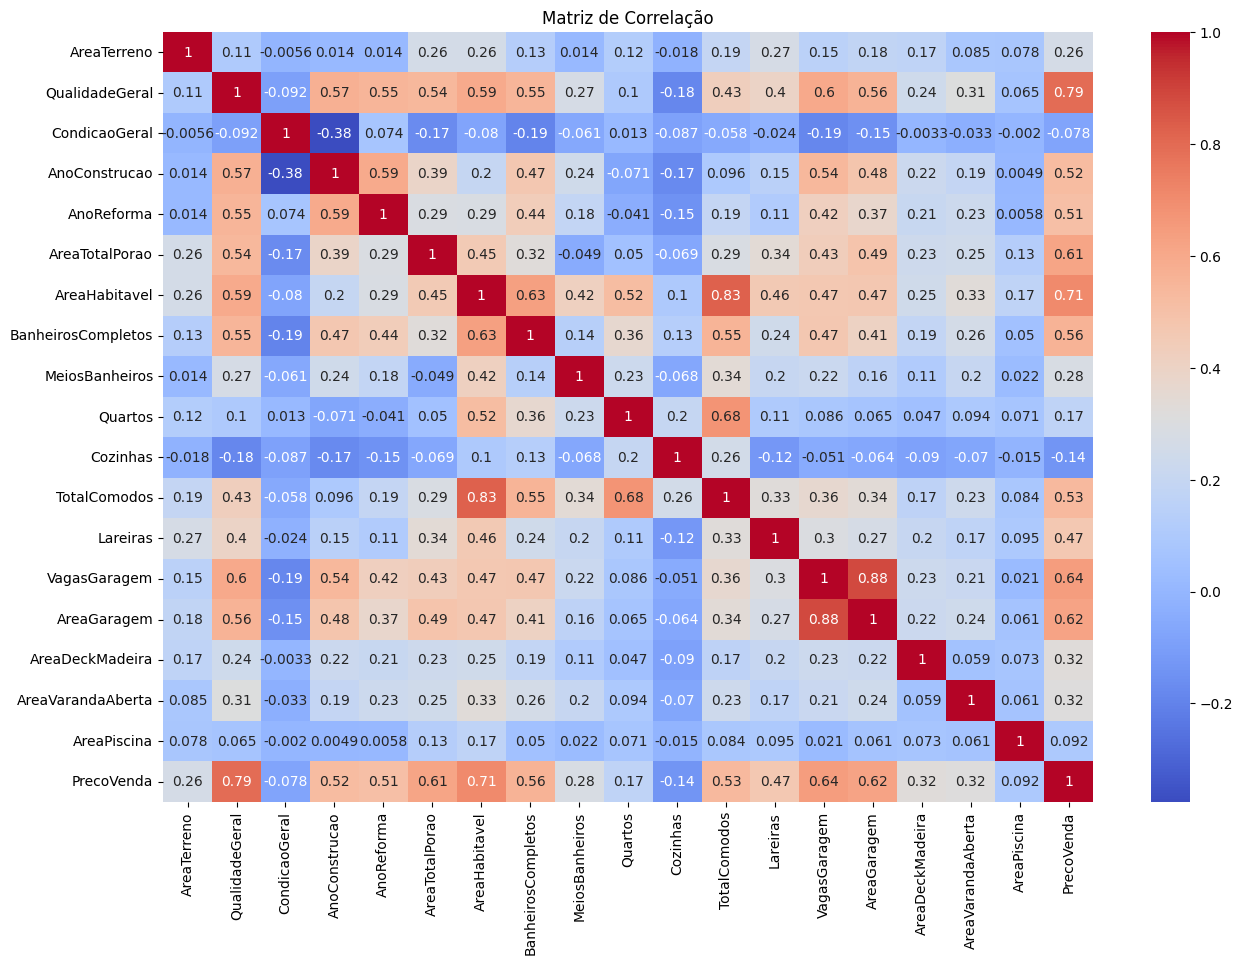

In [ ]:
correlacao = dados[colunas_numericas].corr()

plt.figure(figsize=(15, 10))

sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm"
)

plt.title("Matriz de Correlação")
plt.show()

In [ ]:
# Removendo colunas de acordo com correlação
dados_limpos = dados.copy()

dados_limpos = dados.drop(
      columns=["Cozinhas", "Quartos", "AreaGaragem"]
)

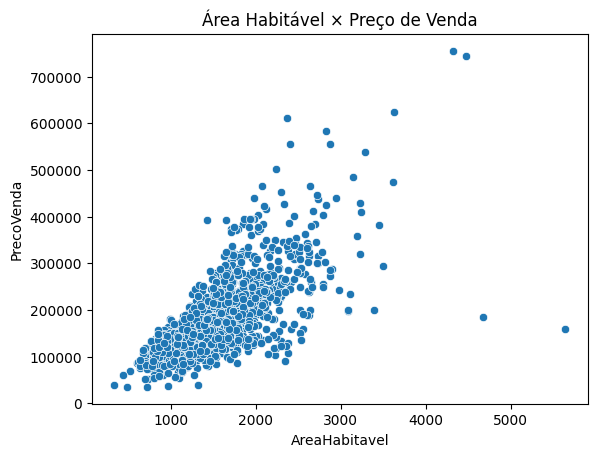

In [ ]:
# Analisando possiveis outliers por correlação

sns.scatterplot(
    data = dados_limpos,
    x="AreaHabitavel",
    y="PrecoVenda"
)

plt.title("Área Habitável × Preço de Venda")
plt.show()
maior_valor = dados_limpos["AreaHabitavel"].max()

dados_limpos = dados_limpos[
    dados_limpos["AreaHabitavel"] != maior_valor
]


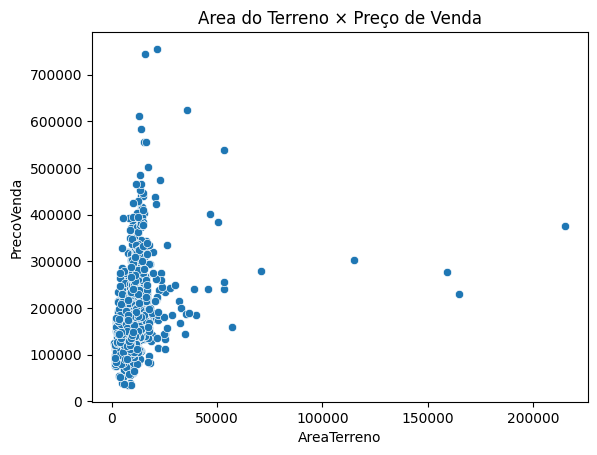

In [ ]:
# AreaTerreno × PrecoVenda


sns.scatterplot(
    data = dados_limpos,
    x="AreaTerreno",
    y="PrecoVenda"
)

plt.title("Area do Terreno × Preço de Venda")
plt.show()


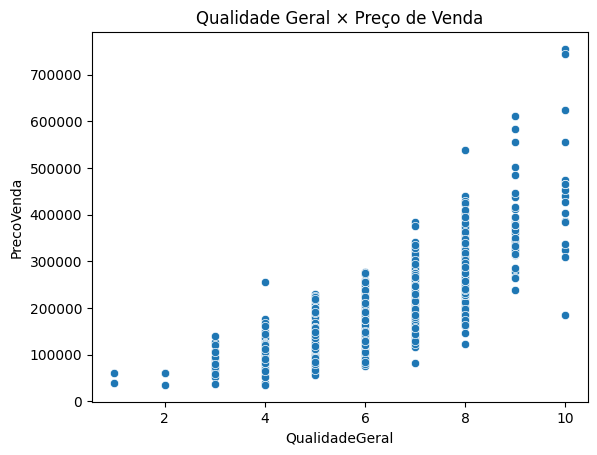

In [ ]:
# QualidadeGeral × PrecoVenda


sns.scatterplot(
    data = dados_limpos,
    x="QualidadeGeral",
    y="PrecoVenda"
)

plt.title("Qualidade Geral × Preço de Venda")
plt.show()


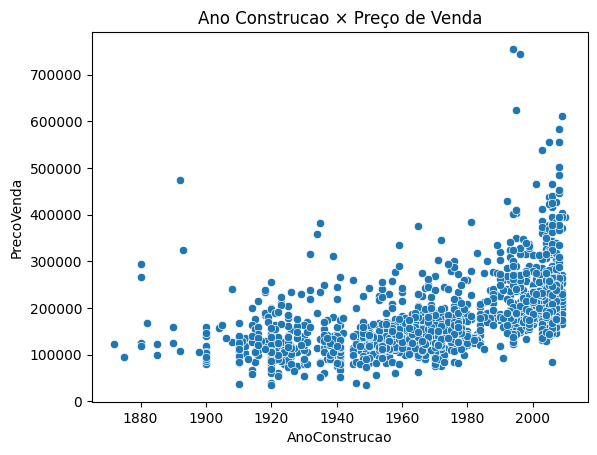

In [ ]:
# AnoConstrucao × PrecoVenda


sns.scatterplot(
    data = dados_limpos,
    x="AnoConstrucao",
    y="PrecoVenda"
)

plt.title("Ano Construcao × Preço de Venda")
plt.show()

maior_valor = dados_limpos[
    (dados_limpos["AnoConstrucao"] < 1900) &
    (dados_limpos["PrecoVenda"] > 400000)
  ]

dados_limpos = dados_limpos.drop(185, errors="ignore")

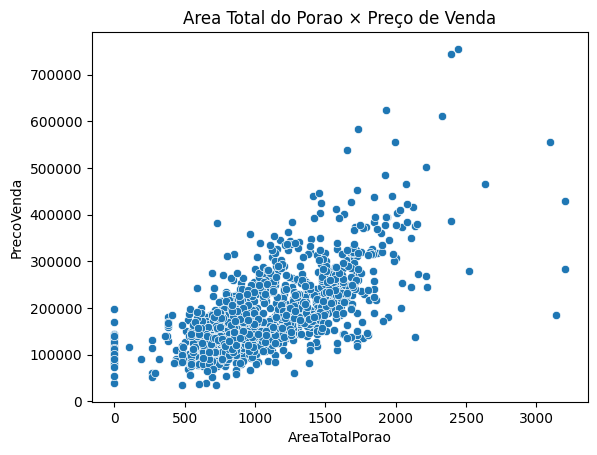

In [ ]:
# AreaTotalPorao × PrecoVenda


sns.scatterplot(
    data = dados_limpos,
    x="AreaTotalPorao",
    y="PrecoVenda"
)

plt.title("Area Total do Porao × Preço de Venda")
plt.show()


#Separação dos Dados

In [ ]:
# Separando dados numéricos e dados categóricos

dados_numericos = dados_limpos.select_dtypes(include=["number"])

dados_categoricos = dados_limpos.select_dtypes(include=["object"])


In [ ]:
print("Colunas numéricas:")
print(dados_numericos.columns)

print("\nColunas categóricas:")
print(dados_categoricos.columns)

Colunas numéricas:
Index(['AreaTerreno', 'QualidadeGeral', 'CondicaoGeral', 'AnoConstrucao',
       'AnoReforma', 'AreaTotalPorao', 'AreaHabitavel', 'BanheirosCompletos',
       'MeiosBanheiros', 'TotalComodos', 'Lareiras', 'VagasGaragem',
       'AreaDeckMadeira', 'AreaVarandaAberta', 'AreaPiscina', 'PrecoVenda'],
      dtype='object')

Colunas categóricas:
Index(['Zoneamento', 'Bairro', 'TipoConstrucao', 'EstiloCasa', 'TipoFundacao',
       'QualidadeExterna', 'CondicaoExterna', 'QualidadeAquecimento',
       'ArCentral', 'QualidadeCozinha', 'TipoGaragem', 'AcabamentoGaragem',
       'PavimentacaoEntrada', 'QualidadePiscina', 'CondicaoVenda'],
      dtype='object')


In [ ]:
# Separando os dados x e y

y = dados_limpos["PrecoVenda"]
X = dados_limpos.drop("PrecoVenda", axis=1)
print("X:", X.shape)
print("y:", y.shape)

print(X.columns)

X: (1458, 30)
y: (1458,)
Index(['Zoneamento', 'AreaTerreno', 'Bairro', 'TipoConstrucao', 'EstiloCasa',
       'QualidadeGeral', 'CondicaoGeral', 'AnoConstrucao', 'AnoReforma',
       'TipoFundacao', 'QualidadeExterna', 'CondicaoExterna', 'AreaTotalPorao',
       'QualidadeAquecimento', 'ArCentral', 'AreaHabitavel',
       'BanheirosCompletos', 'MeiosBanheiros', 'QualidadeCozinha',
       'TotalComodos', 'Lareiras', 'TipoGaragem', 'AcabamentoGaragem',
       'VagasGaragem', 'PavimentacaoEntrada', 'AreaDeckMadeira',
       'AreaVarandaAberta', 'AreaPiscina', 'QualidadePiscina',
       'CondicaoVenda'],
      dtype='object')


In [ ]:
# Dividir os dados de treino e teste

from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_treino:", X_treino.shape)
print("X_teste:", X_teste.shape)
print("y_treino:", y_treino.shape)
print("y_teste:", y_teste.shape)

X_treino: (1166, 30)
X_teste: (292, 30)
y_treino: (1166,)
y_teste: (292,)


#Padronização dos Dados

In [ ]:
# Transformar variáveis categóricas em números

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_treino_categorico = X_treino.select_dtypes(include=["object"])

X_teste_categorico = X_teste.select_dtypes(include=["object"])

In [ ]:
# Fit transform no treino e transform no teste

X_treino_codificado = encoder.fit_transform(X_treino_categorico)

X_teste_codificado = encoder.transform(X_teste_categorico)

print(X_treino_categorico.shape)
print(X_teste_categorico.shape)

print(X_treino_codificado.shape)
print(X_teste_codificado.shape)

(1166, 15)
(292, 15)
(1166, 92)
(292, 92)


In [ ]:
# Juntando colunas numéricas com as categóricas

X_treino_numerico = X_treino.select_dtypes(include=["number"])

X_teste_numerico = X_teste.select_dtypes(include=["number"])


X_treino_final = np.hstack([
    X_treino_numerico,
    X_treino_codificado
])

X_teste_final = np.hstack([
    X_teste_numerico,
    X_teste_codificado
])

print("X_treino_final:", X_treino_final.shape)
print("X_teste_final:", X_teste_final.shape)

X_treino_final: (1166, 107)
X_teste_final: (292, 107)


In [ ]:
# Padronizandoos os dados numéricos e juntando os dados

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_treino_numerico_padronizado = scaler.fit_transform(X_treino_numerico)
X_teste_numerico_padronizado = scaler.transform(X_teste_numerico)


X_treino_final = np.hstack([
    X_treino_numerico_padronizado,
    X_treino_codificado
])

X_teste_final = np.hstack([
    X_teste_numerico_padronizado,
    X_teste_codificado
])

#Treinamento

In [ ]:
# Treinando modelo usando regressão linear

from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X_treino_final, y_treino)

LinearRegression()

#Previsões

In [ ]:
# Previsões

y_pred = modelo.predict(X_teste_final)

In [ ]:
print("Preços reais:")
print(y_teste.head())

print("\nPreços previstos:")
print(y_pred[:5])

Preços reais:
1322    190000
837     100000
414     228000
523     184750
1036    315500
Name: PrecoVenda, dtype: int64

Preços previstos:
[248403.50169503  91207.72963269 239764.11102436 593350.74657927
 288741.50237007]


#Avaliação

In [ ]:
# Avaliando o modelo

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_teste, y_pred)

print("MAE:", mae)

rmse = np.sqrt(mean_squared_error(y_teste, y_pred))

print("RMSE:", rmse)

r2 = r2_score(y_teste, y_pred)

print("R²:", r2)

MAE: 18409.63861502918
RMSE: 35731.3651176866
R²: 0.7623959085769652


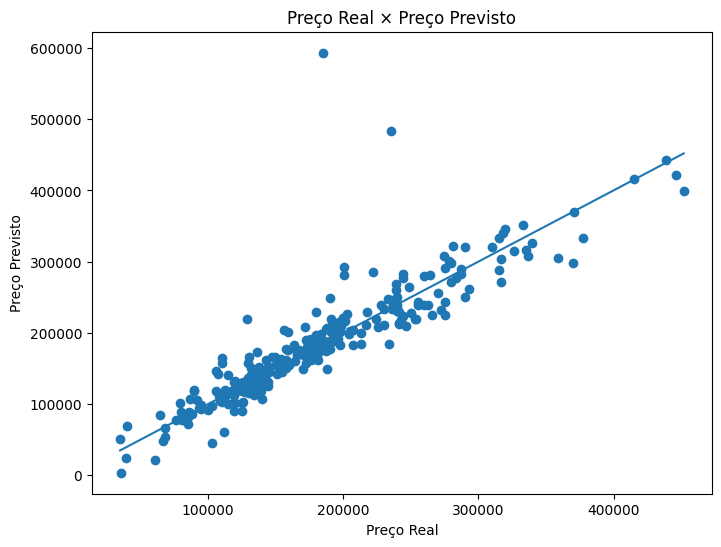

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_teste, y_pred)

plt.plot(
    [y_teste.min(), y_teste.max()],
    [y_teste.min(), y_teste.max()]
)

plt.xlabel("Preço Real")
plt.ylabel("Preço Previsto")
plt.title("Preço Real × Preço Previsto")

plt.show()

#API

In [ ]:
# Rodar no terminal: py -m uvicorn api:app --reload
# Abrir na Web: http://127.0.0.1:8000

In [ ]:
# casa simples
{
  "Zoneamento": "RL",
  "AreaTerreno": 5000,
  "Bairro": "Edwards",
  "TipoConstrucao": "1Fam",
  "EstiloCasa": "1Story",
  "QualidadeGeral": 4,
  "CondicaoGeral": 5,
  "AnoConstrucao": 1960,
  "AnoReforma": 1960,
  "TipoFundacao": "CBlock",
  "QualidadeExterna": "TA",
  "CondicaoExterna": "TA",
  "AreaTotalPorao": 600,
  "QualidadeAquecimento": "TA",
  "ArCentral": "Y",
  "AreaHabitavel": 1000,
  "BanheirosCompletos": 1,
  "MeiosBanheiros": 0,
  "QualidadeCozinha": "TA",
  "TotalComodos": 5,
  "Lareiras": 0,
  "TipoGaragem": "Detchd",
  "AcabamentoGaragem": "Unf",
  "VagasGaragem": 1,
  "PavimentacaoEntrada": "Y",
  "AreaDeckMadeira": 0,
  "AreaVarandaAberta": 20,
  "AreaPiscina": 0,
  "QualidadePiscina": "NoPool",
  "CondicaoVenda": "Normal"
}

In [ ]:
# Casa média

{
  "Zoneamento": "RL",
  "AreaTerreno": 8000,
  "Bairro": "NAmes",
  "TipoConstrucao": "1Fam",
  "EstiloCasa": "1Story",
  "QualidadeGeral": 6,
  "CondicaoGeral": 6,
  "AnoConstrucao": 1995,
  "AnoReforma": 2005,
  "TipoFundacao": "PConc",
  "QualidadeExterna": "Gd",
  "CondicaoExterna": "Gd",
  "AreaTotalPorao": 900,
  "QualidadeAquecimento": "Gd",
  "ArCentral": "Y",
  "AreaHabitavel": 1600,
  "BanheirosCompletos": 2,
  "MeiosBanheiros": 1,
  "QualidadeCozinha": "Gd",
  "TotalComodos": 7,
  "Lareiras": 1,
  "TipoGaragem": "Attchd",
  "AcabamentoGaragem": "RFn",
  "VagasGaragem": 2,
  "PavimentacaoEntrada": "Y",
  "AreaDeckMadeira": 100,
  "AreaVarandaAberta": 40,
  "AreaPiscina": 0,
  "QualidadePiscina": "NoPool",
  "CondicaoVenda": "Normal"
}

In [ ]:
# Casa grande

{
  "Zoneamento": "RL",
  "AreaTerreno": 12000,
  "Bairro": "NridgHt",
  "TipoConstrucao": "1Fam",
  "EstiloCasa": "2Story",
  "QualidadeGeral": 8,
  "CondicaoGeral": 7,
  "AnoConstrucao": 2008,
  "AnoReforma": 2008,
  "TipoFundacao": "PConc",
  "QualidadeExterna": "Ex",
  "CondicaoExterna": "Gd",
  "AreaTotalPorao": 1500,
  "QualidadeAquecimento": "Ex",
  "ArCentral": "Y",
  "AreaHabitavel": 2800,
  "BanheirosCompletos": 3,
  "MeiosBanheiros": 1,
  "QualidadeCozinha": "Ex",
  "TotalComodos": 10,
  "Lareiras": 2,
  "TipoGaragem": "Attchd",
  "AcabamentoGaragem": "Fin",
  "VagasGaragem": 3,
  "PavimentacaoEntrada": "Y",
  "AreaDeckMadeira": 200,
  "AreaVarandaAberta": 100,
  "AreaPiscina": 0,
  "QualidadePiscina": "NoPool",
  "CondicaoVenda": "Normal"
}

In [ ]:
# Casa de alto padrão

{
  "Zoneamento": "RL",
  "AreaTerreno": 15000,
  "Bairro": "NridgHt",
  "TipoConstrucao": "1Fam",
  "EstiloCasa": "2Story",
  "QualidadeGeral": 10,
  "CondicaoGeral": 9,
  "AnoConstrucao": 2010,
  "AnoReforma": 2015,
  "TipoFundacao": "PConc",
  "QualidadeExterna": "Ex",
  "CondicaoExterna": "Ex",
  "AreaTotalPorao": 2000,
  "QualidadeAquecimento": "Ex",
  "ArCentral": "Y",
  "AreaHabitavel": 3500,
  "BanheirosCompletos": 4,
  "MeiosBanheiros": 2,
  "QualidadeCozinha": "Ex",
  "TotalComodos": 12,
  "Lareiras": 3,
  "TipoGaragem": "Attchd",
  "AcabamentoGaragem": "Fin",
  "VagasGaragem": 3,
  "PavimentacaoEntrada": "Y",
  "AreaDeckMadeira": 300,
  "AreaVarandaAberta": 150,
  "AreaPiscina": 500,
  "QualidadePiscina": "Ex",
  "CondicaoVenda": "Normal"
}